## EDA

- Vectorizes severity raster to polygons
- Dissolves by class
- Calculates areas
- Plots map
- Overlays with land use for summaries.

**Libraries**

In [1]:
import os
import rasterio
from rasterio import features
import geopandas as gpd
from shapely.geometry import shape
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

**Paths**

In [13]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, r'output\with_qa')
os.makedirs(OUTPUT_DIR, exist_ok=True)

SEVERITY_PATH = os.path.join(OUTPUT_DIR, 'severity_qa.tif')
POLYGONS_PATH = os.path.join(OUTPUT_DIR, 'burn_severity_polygons_qa.gpkg')
LANDUSE_PATH = os.path.join(DATA_DIR, 'landuse_aoi.geojson')


with rasterio.open(SEVERITY_PATH) as src:
    severity = src.read(1)
    transform = src.transform
    crs = src.crs
    nodata = src.nodata


**1. Convert raster to polygons**

In [14]:
records = []

for geom, value in features.shapes(
        severity,
        mask=severity != nodata,
        transform=transform):

    records.append({
        "geometry": shape(geom),
        "severity": int(value)
    })

gdf = gpd.GeoDataFrame(records, crs=crs)

**2. Disolve by severity class (clean perimeters)**

In [15]:
#One polygon per severity class instead of many pixels

gdf_dissolved = gdf.dissolve(by="severity", as_index=False)

**3.A. Area Compromised per severity class**

In [16]:
#Because Sentinel-2 UTM CRS is in meters, area is reliable
gdf_dissolved["area_m2"] = gdf_dissolved.geometry.area
gdf_dissolved["area_ha"] = gdf_dissolved["area_m2"] / 10_000
gdf_dissolved["area_km2"] = gdf_dissolved["area_m2"] / 1_000_000

In [17]:
#Add severity labels (readable output)
severity_labels = {
    0: "Unburned",
    1: "Low",
    2: "Moderate-Low",
    3: "Moderate-High",
    4: "High"
}

gdf_dissolved["severity_label"] = gdf_dissolved["severity"].map(severity_labels)


In [11]:
#Save vector output
gdf_dissolved.to_file(POLYGONS_PATH, driver="GPKG")

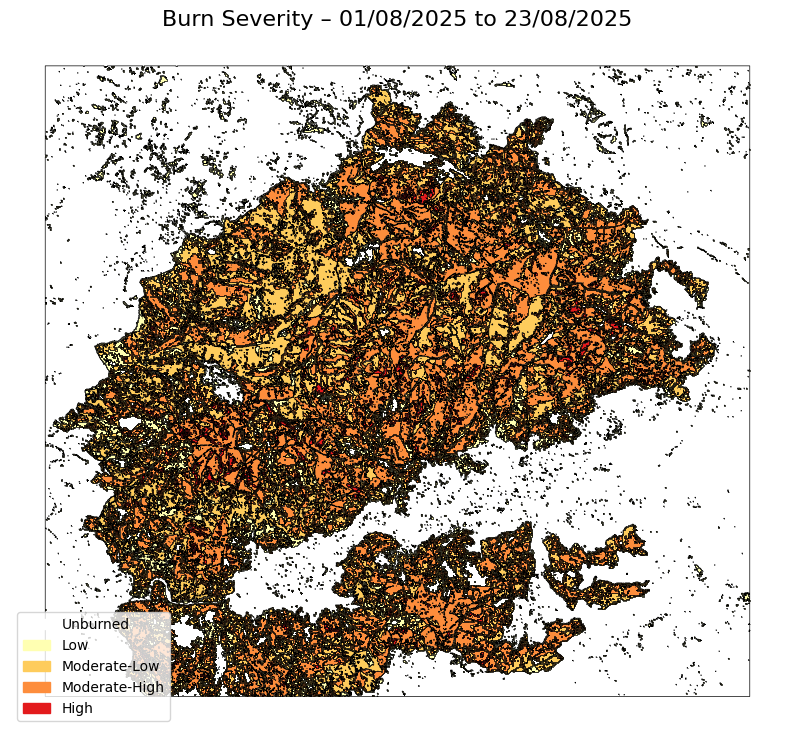

In [12]:
# Color map for severity classes
colors = {
    0: "#ffffff",   # Unburned – white
    1: "#ffffb2",   # Low – light yellow
    2: "#fecc5c",   # Moderate-Low – yellow-orange
    3: "#fd8d3c",   # Moderate-High – orange
    4: "#e31a1c",   # High – red
}

# Map severity column to colors
gdf_dissolved["color"] = gdf_dissolved["severity"].map(colors)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
gdf_dissolved.plot(
    ax=ax,
    color=gdf_dissolved["color"],
    edgecolor="black",
    linewidth=0.5
)

ax.set_title("Burn Severity – 01/08/2025 to 23/08/2025", fontsize=16)
ax.axis("off")

# Optional legend

legend_patches = [
    mpatches.Patch(color=v, label=k) for k, v in zip(
        gdf_dissolved["severity_label"], gdf_dissolved["color"]
    )
]
ax.legend(handles=legend_patches, loc="lower left")

plt.show()


In [18]:
area_table = (
    gdf_dissolved[["severity", "severity_label", "area_ha"]]
    .sort_values("severity")
)

print(area_table)

   severity severity_label   area_ha
0         0       Unburned  37686.64
1         1            Low   5713.12
2         2   Moderate-Low  15335.92
3         3  Moderate-High  14672.48
4         4           High    729.12


In [19]:
area_table.to_csv(
    os.path.join(OUTPUT_DIR, "burn_severity_area_summary_qa.csv"),
    index=False
)

**3.B Land Use Damaged per severity class**

In [7]:
landuse = gpd.read_file(LANDUSE_PATH)
burn = gpd.read_file(POLYGONS_PATH)

print(burn.columns)
print(landuse.columns)

print(burn.crs)
print(landuse.crs)

Index(['severity', 'area_m2', 'area_ha', 'area_km2', 'severity_label',
       'geometry'],
      dtype='object')
Index(['obj_type', 'name', 'info', 'damage_gra', 'det_method', 'notation',
       'or_src_id', 'dmg_src_id', 'cd_value', 'geometry'],
      dtype='object')
EPSG:32629
EPSG:32629


In [8]:
overlay = gpd.overlay(
    burn,
    landuse,
    how="intersection"
)

In [9]:
overlay["area_ha"] = overlay.geometry.area / 10_000

In [10]:
summary = (
    overlay
    .groupby(["severity_label", "info"])["area_ha"]
    .sum()
    .reset_index()
)

print(summary)

   severity_label                                               info  \
0            High              222-Fruit trees and berry plantations   
1            High                   242-Complex cultivation patterns   
2            High  243-Land principally occupied by agriculture, ...   
3            High                            311-Broad-leaved forest   
4            High                              312-Coniferous forest   
5            High                                   313-Mixed forest   
6            High                              321-Natural grassland   
7            High                            322-Moors and heathland   
8            High                    324-Transitional woodland shrub   
9            High                       333-Sparsely vegetated areas   
10           High                                    334-Burnt areas   
11           High                                          998-Other   
12            Low              222-Fruit trees and berry plantat

In [11]:
top3 = (
    summary
    .groupby("severity_label", group_keys=False)
    .apply(lambda x: x.nlargest(3, "area_ha"))
    .reset_index(drop=True)
)

print(top3)

   severity_label                             info      area_ha
0            High          322-Moors and heathland   295.698969
1            High          311-Broad-leaved forest   179.237972
2            High  324-Transitional woodland shrub   133.955388
3             Low          322-Moors and heathland  1571.535929
4             Low            312-Coniferous forest   392.162711
5             Low          311-Broad-leaved forest   263.197738
6   Moderate-High          322-Moors and heathland  8251.675413
7   Moderate-High  324-Transitional woodland shrub  1858.036184
8   Moderate-High            312-Coniferous forest  1531.980118
9    Moderate-Low          322-Moors and heathland  9526.593310
10   Moderate-Low            312-Coniferous forest  1121.868084
11   Moderate-Low          311-Broad-leaved forest  1024.254745
12       Unburned          322-Moors and heathland    88.662016
13       Unburned                        998-Other    78.385069
14       Unburned          311-Broad-lea

C:\Users\User\AppData\Local\Temp\ipykernel_12384\1352987368.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, "area_ha"))


In [ ]:
top3.to_csv(
    os.path.join(OUTPUT_DIR, "top_3_landuse_qa.csv"),
    index=False
)